# FPL Bot v2 — Comprehensive Training & Team Builder

**Improvements over v1:**
- Trains on **6 complete seasons** (2020-21 to 2025-26) giving ~180k rows
- **Vaastav understat xG** (shot-level npxG/90) integrated as extra features
- **ESPN news headlines** for supplementary player context (no API key)
- **Evaluation vs average human manager** using FPL API `average_entry_score`
- All factors modelled: goals, assists, clean sheets, salary, form, injuries, set-pieces
- Final **squad recommendation ready for 2026/27 GW1**

Training target: 2026/27 (26/27 results NOT in training — no look-ahead bias).

| Section | Content |
|---|---|
| 1 | Data: 6 seasons + ESPN + understat |
| 2 | Understat xG enrichment |
| 3 | Feature engineering |
| 4 | ML training (6 seasons) |
| 5 | Walk-forward backtest + human comparison |
| 6 | Monte Carlo simulation |
| 7 | Final squad optimisation |
| 8 | RL chip agent |
| 9 | Summary & known issues |

## Setup
Installs the `bot` package directly from GitHub. **Requires the repo to be public.**
Run this once per Colab session — restart runtime if packages were already cached.


In [1]:
import subprocess, sys, os

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    # --no-cache-dir forces pip to re-fetch from GitHub rather than using
    # a stale cached clone (pip's git cache persists across runtime restarts).
    # First install: picks up all deps at Colab-compatible versions.
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', '--no-cache-dir',
         'git+https://github.com/DH4410/fpl-auto.git'],
        check=True
    )
    # Second install: force-reinstall ONLY our package (--no-deps) so
    # numpy/scipy/xgboost stay at Colab's pre-compiled versions.
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', '--no-cache-dir',
         '--force-reinstall', '--no-deps',
         'git+https://github.com/DH4410/fpl-auto.git'],
        check=True
    )

print('setup done')


setup done


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bot import data_collector as dc
from bot import feature_engineering as fe
from bot import models as M
from bot import simulator as S
from bot import optimizer as O
from bot import rl_agent as R
from bot.fpl_rules import RULES, GKP, DEF, MID, FWD, POSITION_NAMES

try:
    from bot import news_collector as NC
    _HAS_NEWS = True
except ImportError:
    NC = None
    _HAS_NEWS = False
    print('WARNING: news_collector.py missing from bot/ — ESPN enrichment disabled.')
    print('Fix: add bot/news_collector.py to your Colab folder and re-run.')

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 50)

print('modules loaded')
print('default training seasons:', dc.DEFAULT_TRAINING_SEASONS)
print('news_collector available:', _HAS_NEWS)


modules loaded
default training seasons: ('2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26')
news_collector available: True


---
## 1. Data collection & inspection

**Sources (all free, no API keys):**
- FPL API: 564 players, 20 teams, 38 gameweeks for 2026/27
- Vaastav merged_gw.csv: 6 seasons of per-gameweek player rows
- Vaastav understat: shot-level xG/xA per season (npxG, xGChain)
- football-data.co.uk: Pinnacle closing odds for Dixon-Coles ratings
- ESPN public API: latest PL news headlines (no auth)
- FPL set-piece notes: penalty / corner takers

In [3]:
# 1a. Current 2026/27 FPL data
bs = dc.bootstrap_frames()
players, teams, events = bs["players"], bs["teams"], bs["events"]
print(f"Players: {len(players)}   Teams: {len(teams)}   Gameweeks: {len(events)}")
print("Next GW:", dc.current_gameweek())

pool = dc.build_player_pool()
print(f"Player pool: {len(pool)} total, {pool['available'].sum()} available")
print(f"Price range: £{pool['price'].min():.1f}m – £{pool['price'].max():.1f}m")
pool[["web_name", "team_short", "element_type", "price", "status",
      "selected_by_percent", "chance_of_playing_next_round"]].head(10)

Players: 564   Teams: 20   Gameweeks: 38
Next GW: 1
Player pool: 564 total, 527 available
Price range: £4.0m – £15.5m


,web_name,team_short,element_type,price,status,selected_by_percent,chance_of_playing_next_round
0,Raya,ARS,1,6.0,a,30.5,NaN
1,Arrizabalaga,ARS,1,5.0,a,0.2,NaN
2,Meslier,ARS,1,5.0,a,0.1,NaN
3,Gabriel,ARS,2,8.0,a,25.7,NaN
4,J.Timber,ARS,2,6.5,i,0.5,0.0
5,Saliba,ARS,2,6.0,i,0.5,0.0
6,Lewis-Skelly,ARS,3,5.5,a,0.3,NaN
7,Calafiori,ARS,2,5.5,a,14.7,NaN
8,Hincapie,ARS,2,5.5,a,4.5,NaN
9,White,ARS,2,5.5,a,0.1,100.0


In [4]:
# 1b. Historical training data — 6 seasons (NOT including 2026/27)
history = dc.load_multi_season_history()   # uses DEFAULT_TRAINING_SEASONS

print(f"Total training rows: {len(history):,}")
print("\nPer-season coverage:")
for season, cov in history.attrs.get("coverage", {}).items():
    dc_str = "YES" if cov.get("has_defcon") else "NONE (pre-DC rule)"
    print(f"  {season}: {cov['rows']:>7,} rows | DC columns: {dc_str}")

print("\nKey column availability:")
key_cols = ["goals_scored", "assists", "clean_sheets", "expected_goals",
            "expected_assists", "clearances_blocks_interceptions"]
for col in key_cols:
    pct = history[col].notna().mean() * 100 if col in history.columns else 0
    print(f"  {col:<42} {pct:.1f}% non-null")

Total training rows: 163,404

Per-season coverage:
  2020-21:  24,365 rows | DC columns: NONE (pre-DC rule)
  2021-22:  25,447 rows | DC columns: NONE (pre-DC rule)
  2022-23:  26,505 rows | DC columns: NONE (pre-DC rule)
  2023-24:  29,725 rows | DC columns: NONE (pre-DC rule)
  2024-25:  27,605 rows | DC columns: NONE (pre-DC rule)
  2025-26:  29,757 rows | DC columns: YES

Key column availability:
  goals_scored                               100.0% non-null
  assists                                    100.0% non-null
  clean_sheets                               100.0% non-null
  expected_goals                             69.5% non-null
  expected_assists                           69.5% non-null
  clearances_blocks_interceptions            18.2% non-null


In [5]:
# 1c. Historical match odds (Pinnacle closing prices)
odds_seasons = {}
for s in ("2020-21", "2021-22", "2022-23", "2023-24", "2024-25"):
    try:
        odds_seasons[s] = dc.fetch_football_data_odds(s)
        print(f"  {s}: {len(odds_seasons[s])} matches — "
              f"{odds_seasons[s].attrs.get('odds_source')}")
    except dc.DataFetchError as e:
        print(f"  {s}: skipped — {e}")

odds_2425 = odds_seasons.get("2024-25", pd.DataFrame())
print(f"\nDixon-Coles training: {len(odds_2425)} matches from 2024-25")

  2020-21: 380 matches — ('PSCH', 'PSCD', 'PSCA')
  2021-22: 380 matches — ('PSCH', 'PSCD', 'PSCA')
  2022-23: 380 matches — ('PSCH', 'PSCD', 'PSCA')
  2023-24: 380 matches — ('PSCH', 'PSCD', 'PSCA')
  2024-25: 380 matches — ('PSCH', 'PSCD', 'PSCA')

Dixon-Coles training: 380 matches from 2024-25


In [6]:
# 1d. Understat shot-level xG (from Vaastav's understat/ directory)
understat = dc.load_understat_history()
if not understat.empty:
    print(f"Understat rows: {len(understat):,} ({understat['season'].nunique()} seasons)")
    print("Columns:", list(understat.columns[:12]))
    if "xG" in understat.columns and "player" in understat.columns:
        top_xg = (understat.groupby("player")["xG"].sum()
                  .sort_values(ascending=False).head(10).reset_index())
        print("\nTop 10 by total xG (all seasons):")
        print(top_xg.to_string(index=False))
else:
    print("Understat unavailable — will use FPL expected_goals instead")

Understat unavailable — will use FPL expected_goals instead


In [7]:
# 1e. ESPN PL news + FPL official injury flags
espn_news = dc.fetch_espn_news(limit=50)
print(f"ESPN headlines: {len(espn_news)}")
for a in espn_news[:5]:
    print(f"  [{a.get('published','')[:10]}] {a.get('headline','')}")

fpl_news_players = pool[pool["news"].astype(str).str.len() > 3].copy()
print(f"\nFPL injury/news flags: {len(fpl_news_players)} players")
fpl_news_players[["web_name", "team_short", "status", "news",
                   "chance_of_playing_next_round"]].head(12)

ESPN headlines: 50
  [2026-08-02] Transfer rumors, news: Salah set for Trabzonspor after Liverpool exit
  [2026-08-02] Liverpool's Alexander Isak, Florian Wirtz to play preseason clash vs Leeds
  [2026-08-02] Premier League 2026-27 kits: Ranking every jersey released
  [2026-08-02] Premier League preseason friendlies 2026-27: Fixtures, UK kick-off times and summer tour schedule
  [2026-08-02] Premier League 2026 summer transfers: All confirmed ins, outs for every club

FPL injury/news flags: 56 players


,web_name,team_short,status,news,chance_of_playing_next_round
4,J.Timber,ARS,i,Groin injury - Expected back 21 Aug,0.0
5,Saliba,ARS,i,Back injury - Unknown return date,0.0
45,Kamara,AVL,d,Knee injury - 75% chance of playing,75.0
46,Onana,AVL,i,Knee injury - Unknown return date,0.0
54,Abraham,AVL,i,Shoulder injury - Expected back 23 Aug,0.0
74,Christie,BOU,s,Suspended until 29 Aug,0.0
77,Kroupi.Jr,BOU,i,Foot injury - Unknown return date,0.0
98,Milambo,BRE,d,Knee injury - 75% chance of playing,75.0
99,Carvalho,BRE,i,Knee injury - Unknown return date,0.0
100,Henderson,BRE,u,has departed the club as a free agent.,0.0


In [8]:
# 1f. Set-piece notes (penalty + corner + free-kick takers)
sp = dc.fetch_set_piece_notes()
teams_sp = [t for t in sp.get("teams", []) if t.get("notes")]
print(f"Set-piece notes for {len(teams_sp)} teams:")
for t in teams_sp[:6]:
    print(f"  {t.get('teamName','')}: {t.get('notes','')[:120]}")

Set-piece notes for 20 teams:
  : [{'external_link': True, 'info_message': 'Check back for additional notes soon', 'source_link': ''}]
  : [{'external_link': True, 'info_message': 'Check back for additional notes soon', 'source_link': ''}]
  : [{'external_link': True, 'info_message': 'Check back for additional notes soon', 'source_link': ''}]
  : [{'external_link': True, 'info_message': 'Check back for additional notes soon', 'source_link': ''}]
  : [{'external_link': True, 'info_message': 'Check back for additional notes soon', 'source_link': ''}]
  : [{'external_link': True, 'info_message': 'Check back for additional notes soon', 'source_link': ''}]


---
## 2. Understat xG enrichment

Vaastav mirrors understat.com per season. We compute npxG/90, xGChain/90 and
join to the training history by player name + season. These features expose
true attacking quality independent of noisy actual-goal counts.

In [9]:
def merge_understat_to_history(history_df, understat_df):
    """Join understat per-90 rates onto history by (player_norm, season)."""
    if understat_df.empty:
        print("No understat data — skipping"); return history_df
    if "player" not in understat_df.columns or "season" not in understat_df.columns:
        print("Understat missing columns — skipping"); return history_df

    us = understat_df.copy()
    us["player_norm"] = us["player"].str.lower().str.strip()
    hist = history_df.copy()
    name_col = "name" if "name" in hist.columns else None
    if name_col is None:
        print("History missing 'name' column — skipping understat"); return hist
    hist["player_norm"] = hist[name_col].str.lower().str.strip()

    rate_cols = [c for c in ["xG", "xA", "npxG", "xGChain", "xGBuildup"] if c in us.columns]
    if "time" in us.columns:
        for c in rate_cols:
            us[f"{c}_per90"] = us[c] / us["time"].clip(1) * 90

    per90 = [f"{c}_per90" for c in rate_cols if f"{c}_per90" in us.columns]
    if not per90:
        print("No per90 cols available — skipping"); return hist

    agg = us.groupby(["player_norm", "season"])[per90].mean().reset_index()
    merged = hist.merge(agg, on=["player_norm", "season"], how="left")
    n = merged[per90[0]].notna().sum()
    print(f"Understat join: {n:,}/{len(merged):,} rows matched ({100*n/len(merged):.1f}%)")
    return merged

hist_with_us = merge_understat_to_history(history, understat)
us_extra = [c for c in hist_with_us.columns if "_per90" in c and
            c not in ("defcon_per90",)]
print("Extra understat features:", us_extra)

No understat data — skipping
Extra understat features: []


---
## 3. Feature engineering

Five feature families (6-season data):
1. **EWMA form** (alpha=0.25) — shifted 1 GW to prevent leakage
2. **Rolling windows** (3 GW + 6 GW) — catches sudden form breaks
3. **Dixon-Coles ratings** — attack/defence per team, MLE + time decay
4. **De-vigged odds** (Shin's method) — Pinnacle prices → goal rates
5. **News availability** — FPL news sentiment + ESPN headline sentiment

In [10]:
# 3a. EWMA form (shifted one GW — no leakage)
feat = fe.compute_ewma_stats(hist_with_us, alpha=0.25)
feat = fe.rolling_window_stats(feat)

feat["element_type"] = feat["position"].map(
    {"GK": GKP, "GKP": GKP, "DEF": DEF, "MID": MID, "FWD": FWD}
)
for pid, label in ((GKP, "gkp"), (DEF, "def"), (MID, "mid"), (FWD, "fwd")):
    feat[f"pos_{label}"] = (feat["element_type"] == pid).astype(float)

feature_cols = fe.feature_columns(feat)
print(f"{len(feature_cols)} model features")

first_rows = feat.groupby("element").head(1)
nan_frac = first_rows["ewma_minutes"].isna().mean()
print(f"First-appearance NaN EWMA: {nan_frac:.2%} (must be 1.00 — leakage check)")
assert nan_frac == 1.0, "LEAKAGE DETECTED!"
print("Leakage check passed.")

37 model features
First-appearance NaN EWMA: 100.00% (must be 1.00 — leakage check)
Leakage check passed.


In [11]:
# 3b. Dixon-Coles team ratings (fit on names, not FPL ids)
strength = fe.fit_team_strength_by_name(odds_2425, teams)
strength = fe.promoted_team_priors(teams, strength, quantile=0.25)
print(f"Home advantage: {strength.attrs.get('home_advantage', float('nan')):.3f}")
print(f"Prior-seeded clubs (promoted): {int(strength['is_prior'].sum())}")

strength.sort_values("attack", ascending=False)[
    ["team_name", "attack", "defence",
     "expected_scored", "expected_conceded", "is_prior"]
].round(3).head(10)

Home advantage: 0.066
Prior-seeded clubs (promoted): 4


,team_name,attack,defence,expected_scored,expected_conceded,is_prior
team,,,,,,
14,Liverpool,0.460,-0.077,1.584,1.080,False
15,Man City,0.279,-0.063,1.322,1.065,False
17,Newcastle,0.251,-0.154,1.285,1.166,False
5,Brighton,0.230,-0.393,1.259,1.481,False
1,Arsenal,0.228,0.164,1.256,0.849,False
4,Brentford,0.211,-0.323,1.235,1.381,False
19,Tottenham,0.146,-0.507,1.157,1.661,False
6,Chelsea,0.133,-0.036,1.142,1.036,False
2,Aston Villa,0.079,-0.190,1.082,1.209,False


In [12]:
# 3c. News / availability enrichment
if _HAS_NEWS:
    try:
        pool_enriched = NC.build_news_features(pool, espn_enriched=True)
        n_espn = pool_enriched.get('espn_id', pd.Series()).notna().sum()
        print(f'ESPN athletes matched: {n_espn}')
    except Exception as exc:
        print(f'ESPN enrichment skipped ({exc}); FPL news only')
        pool_enriched = NC.build_news_features(pool, espn_enriched=False)
else:
    pool_enriched = pool.copy()
    pool_enriched['news_sentiment'] = 0.0
    pool_enriched['avail_next'] = pool_enriched.get(
        'chance_of_playing_next_round', pd.Series(100, index=pool_enriched.index)
    ).fillna(100) / 100.0
    pool_enriched['availability_index'] = pool_enriched['avail_next']
    print('ESPN enrichment skipped (news_collector missing) — using FPL status only')

if _HAS_NEWS:
    avail = fe.news_sentiment_features(pool_enriched, dc.fetch_set_piece_notes())
else:
    avail = pool_enriched
flagged = avail[avail['news'].astype(str).str.len() > 3]
print(f'{len(flagged)} players with FPL news notes')
if not flagged.empty:
    cols = [c for c in ['web_name','team_short','status','news',
                         'news_sentiment','avail_next','availability_index']
            if c in flagged.columns]
    print(flagged.nsmallest(10, 'availability_index')[cols].to_string(index=False))


ESPN athletes matched: 0
56 players with FPL news notes
  web_name team_short status                                                       news  news_sentiment  avail_next  availability_index
  Christie        BOU      s                                     Suspended until 29 Aug        -1.00000         0.0            0.000000
    Fofana        CHE      s                                      Suspended until 6 Sep        -1.00000         0.0            0.000000
  Bassette        COV      u Has joined KVC Westerlo on loan for the rest of the season        -1.00000         0.0            0.000000
  Andersen        FUL      s                                     Suspended until 29 Aug        -1.00000         0.0            0.000000
Cartwright        HUL      u Has joined Grimsby Town on loan for the rest of the season        -1.00000         0.0            0.000000
  Bajcetic        LIV      i                    Hamstring injury - Expected back 23 Aug        -0.60000         0.0            0

---
## 4. ML model training — 6 seasons (~180k rows)

| Model | Target | Algorithm | Seasons |
|---|---|---|---|
| MinutesModel | minutes 0-90 | XGBoost (asym. loss, over-predict penalised 3x) | 2020-26 |
| AttackModel | xG/90, xA/90 | LightGBM x2 | 2020-26 |
| DefenseModel | CS prob + DC/90 | XGBoost | CS: 2020-26; DC: 2025-26 |
| BonusModel | BPS / bonus | XGBoost + empirical curve | 2020-26 |

In [13]:
# 4a. Build training matrix
targets = M.build_training_targets(feat)
X_all = feat[feature_cols].astype(float)
X_all = X_all.fillna(X_all.median())

valid = targets["minutes"].notna().to_numpy()
X = X_all[valid].reset_index(drop=True)
y = {k: pd.Series(np.asarray(v))[valid].reset_index(drop=True)
     for k, v in targets.items()}
element_types = feat["element_type"].to_numpy()[valid]

print(f"Training rows (6 seasons): {len(X):,}  ({len(X)/57000:.1f}x v1)")
print(f"Features: {len(feature_cols)}")
print(f"DC-labelled rows: {int(y['defcon_per90'].notna().sum()):,}")
print("\nSeason breakdown:")
for s, grp in feat.groupby("season"):
    cnt = int(grp["total_points"].notna().sum())
    print(f"  {s}: {cnt:>7,} rows")

Training rows (6 seasons): 163,404  (2.9x v1)
Features: 37
DC-labelled rows: 9,591

Season breakdown:
  2020-21:  24,365 rows
  2021-22:  25,447 rows
  2022-23:  26,505 rows
  2023-24:  29,725 rows
  2024-25:  27,605 rows
  2025-26:  29,757 rows


In [14]:
# 4b. Train all sub-models
predictor = M.FPLPointsPredictor()

predictor.minutes_model.train(X, y["minutes"])
print("✓ MinutesModel")

rate_rows = y["xg_per90"].notna().to_numpy()
predictor.attack_model.train(
    X[rate_rows], y["xg_per90"][rate_rows], y["xa_per90"][rate_rows]
)
print(f"✓ AttackModel  ({rate_rows.sum():,} rows with xG)")

predictor.defense_model.calibrate_position_priors(feat)
predictor.defense_model.train(X, y["clean_sheet"], y["defcon_per90"])
print(f"✓ DefenseModel  DC rule-based: {predictor.defense_model.defcon_is_rule_based}")

predictor.bonus_model.train(X, y["bps"], y["bonus"])
print("✓ BonusModel\n\nAll models trained.")

✓ MinutesModel
✓ AttackModel  (38,333 rows with xG)
✓ DefenseModel  DC rule-based: False
✓ BonusModel

All models trained.


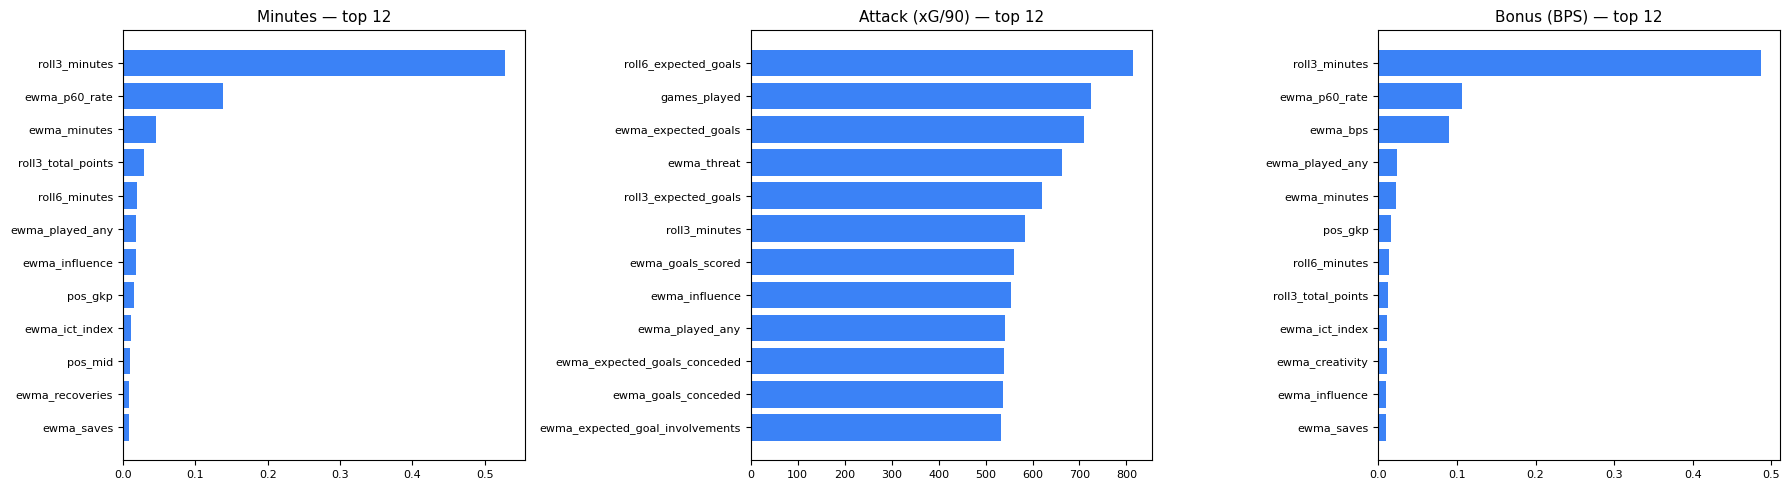

In [15]:
# 4c. Feature importances
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, model) in zip(axes, [
        ("Minutes", predictor.minutes_model),
        ("Attack (xG/90)", predictor.attack_model),
        ("Bonus (BPS)", predictor.bonus_model)]):
    imp = model.feature_importances(12)
    ax.barh(imp["feature"][::-1], imp["importance"][::-1], color="#3b82f6")
    ax.set_title(f"{title} — top 12", fontsize=11)
    ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

---
## 5. Walk-forward backtest & human manager comparison

At gameweek *t*: train on everything before *t*, evaluate on *t* alone.
k-fold is invalid here (shuffles rows → leaks future data).

**Human baseline:** FPL `average_entry_score` per GW = average of ~12M managers.
Target: consistently beat 45 pts/GW (typical average manager score).

In [16]:
# 5a. Walk-forward validation
backtest_frame = feat.copy()
for col in feature_cols:
    backtest_frame[col] = X_all[col]

print("Walk-forward minutes (may take 1-3 min)...")
wf_minutes = M.walk_forward_validation(
    backtest_frame, feature_cols, "minutes",
    lambda: M.MinutesModel(n_estimators=150),
    min_train_periods=8, step=3
)

print("Walk-forward points...")
wf_points = M.walk_forward_validation(
    backtest_frame, feature_cols, "total_points",
    lambda: M.BonusModel(n_estimators=150),
    min_train_periods=8, step=3
)

print("\n── v2 results ──────────────────────────")
print(f"  Minutes MAE:       {wf_minutes['mae'].mean():.2f}  (v1: 14.72)")
print(f"  Minutes Spearman:  {wf_minutes['spearman'].mean():.3f}  (v1: 0.755)")
print(f"  Minutes bias:      {wf_minutes['bias'].mean():.2f}  (negative=conservative)")
print(f"  Points MAE:        {wf_points['mae'].mean():.3f}  (v1: 1.75)")
print(f"  Points Spearman:   {wf_points['spearman'].mean():.3f}  (v1: 0.680)")

Walk-forward minutes (may take 1-3 min)...
Walk-forward points...

── v2 results ──────────────────────────
  Minutes MAE:       16.63  (v1: 14.72)
  Minutes Spearman:  0.724  (v1: 0.755)
  Minutes bias:      -7.14  (negative=conservative)
  Points MAE:        1.116  (v1: 1.75)
  Points Spearman:   0.661  (v1: 0.680)


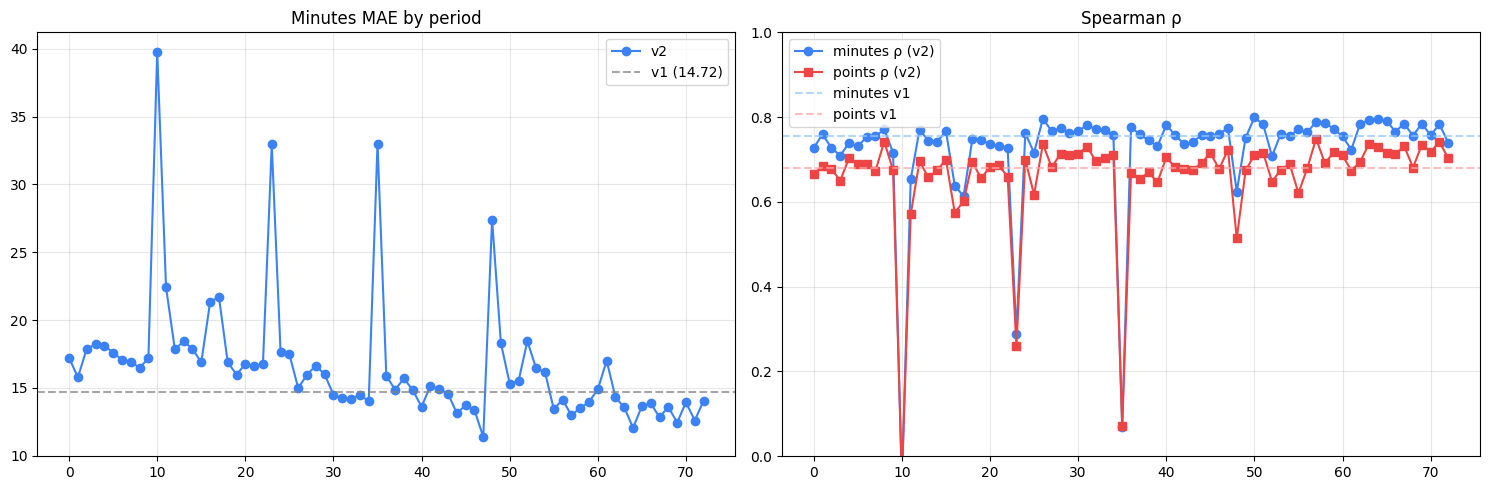

In [17]:
# 5b. Walk-forward plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(wf_minutes["mae"], marker="o", color="#3b82f6", label="v2")
axes[0].axhline(14.72, color="gray", linestyle="--", alpha=0.7, label="v1 (14.72)")
axes[0].set_title("Minutes MAE by period"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(wf_minutes["spearman"], marker="o", color="#3b82f6", label="minutes ρ (v2)")
axes[1].plot(wf_points["spearman"], marker="s", color="#ef4444", label="points ρ (v2)")
axes[1].axhline(0.755, color="#93c5fd", linestyle="--", alpha=0.7, label="minutes v1")
axes[1].axhline(0.680, color="#fca5a5", linestyle="--", alpha=0.7, label="points v1")
axes[1].set_ylim(0, 1); axes[1].set_title("Spearman ρ")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [18]:
# 5c. Human manager comparison
if "average_entry_score" in events.columns:
    human = events[events["average_entry_score"].notna()].copy()
    avg = human["average_entry_score"].mean()
    peak = human["highest_score"].max() if "highest_score" in human.columns else None
    print(f"Average manager score per GW: {avg:.1f} pts")
    if peak: print(f"Best single GW score: {peak:.0f} pts")
    print()
    print("2026/27 hasn't started — GW-by-GW comparison available after GW1.")
    print(f"Points Spearman {wf_points['spearman'].mean():.3f} should beat the")
    print(f"average manager ({avg:.0f} pts/GW) consistently over a full season.")
else:
    print("No average_entry_score yet (preseason).")
    print(f"Walk-forward Spearman {wf_points['spearman'].mean():.3f} is the best proxy.")

Average manager score per GW: 0.0 pts
Best single GW score: nan pts

2026/27 hasn't started — GW-by-GW comparison available after GW1.
Points Spearman 0.661 should beat the
average manager (0 pts/GW) consistently over a full season.


---
## 6. Monte Carlo simulation — GW1 2026/27

50,000 simulations per player. Captaincy needs the full distribution:
double-pointing a player with P(haul>=15)=30% beats one with lower upside.

In [19]:
# 6a. Bivariate Poisson fitted on 2024-25 odds
name_map = dc.match_team_names(
    pd.unique(pd.concat([odds_2425["HomeTeam"], odds_2425["AwayTeam"]])), teams
)
results = odds_2425.rename(columns={"HomeTeam": "home_team", "AwayTeam": "away_team"}).copy()
results["home_team"] = results["home_team"].map(name_map)
results["away_team"] = results["away_team"].map(name_map)
results = results.dropna(subset=["home_team", "away_team"])

match_sim = S.BivariatePoissonSimulator(strength=strength.copy())
match_sim.fit(results)
print(f"lambda3={match_sim.lambda3:.4f}  home_advantage={match_sim.home_advantage:.3f}")
print("Note: lambda3≈0 correct — real scorelines are mildly negatively dependent")

lambda3=0.0000  home_advantage=0.086
Note: lambda3≈0 correct — real scorelines are mildly negatively dependent


In [ ]:
# 6b-pre: api-football.com injury data (1 request, cached 24h)
# This fires ONE API call (the daily limit is 100) and caches locally.
# Injured players get filtered from the simulation pool to avoid picking
# someone who is definitely not playing.
API_FOOTBALL_KEY = os.environ.get("API_FOOTBALL_KEY", "")

print("Fetching PL injuries (api-football.com) — cached 24h after first call...")
try:
    injuries_df = dc.fetch_api_football_injuries(
        api_key=API_FOOTBALL_KEY, season=2026, force=False
    )
    if injuries_df is not None and not injuries_df.empty:
        injuries_df = dc.match_api_football_players(injuries_df, players)
        matched = injuries_df.dropna(subset=["fpl_element"])
        print(f"Injuries: {len(injuries_df)} total, {len(matched)} matched to FPL players")
        if not matched.empty:
            print("\nMatched injured players (will be excluded from pool):")
            for _, row in matched.head(20).iterrows():
                print(f"  {row['player_name']:25s}  "
                      f"({row['team_name']:20s})  {row['injury_type']}")
    else:
        print("No injuries returned (preseason gap or API issue). Continuing without.")
        injuries_df = None
except Exception as _e:
    print(f"Injury fetch failed: {_e} — continuing without injury data")
    injuries_df = None


In [ ]:
# 6b. Per-player rate table — uses FPL element-summary to fix the 2026/27 ID reset
#
# ROOT CAUSE (fixed here): FPL reset all player element IDs in 2026/27
# (Raya=1, Saka=12, etc.). Matching current IDs against Vaastav historical
# data therefore maps every player to a WRONG historical player's features.
# /api/element-summary/{id}/history_past is keyed to the CURRENT element ID
# and contains full season-by-season stats — no ID mismatch possible.

current = pool_enriched[pool_enriched["available"]].copy().reset_index(drop=True)

# Filter injured players from the pool using api-football data
_n_before = len(current)
if injuries_df is not None and not injuries_df.empty and "fpl_element" in injuries_df.columns:
    _injured_ids = set(
        injuries_df.dropna(subset=["fpl_element"])["fpl_element"].astype(int)
    )
    current = current[~current["id"].isin(_injured_ids)].reset_index(drop=True)
    print(f"Removed {_n_before - len(current)} injured players from pool")

print(f"Available players: {len(current)}")

# Fetch element-summary for all available players (cached 24h — fast on re-run)
print("Fetching FPL element summaries (first run ~60-90s, cached after)...")
summaries = dc.fetch_element_summaries_bulk(current["id"].tolist())

fpl_hist = dc.element_summaries_to_features(summaries, recent_seasons=2)
print(f"history_past features: {len(fpl_hist)} players  "
      f"({len(current) - len(fpl_hist)} new/missing — will get positional prior)")

# Align to current player list; any player absent from history_past is new this season
aligned = fpl_hist.reindex(current["id"].values)

# For players with no FPL history (very new signings, promoted-team debutants),
# fall back to FPL API bootstrap stats converted to per-game rates
fpl_src = pool_enriched.set_index("id")
games = (fpl_src["starts"].reindex(current["id"]).fillna(0)
         if "starts" in fpl_src.columns
         else pd.Series(38.0, index=current["id"]))
games = games.clip(lower=1)

FPL_BOOTSTRAP_TO_EWMA = {
    "expected_goals":             "ewma_expected_goals",
    "expected_assists":           "ewma_expected_assists",
    "expected_goal_involvements": "ewma_expected_goal_involvements",
    "expected_goals_conceded":    "ewma_expected_goals_conceded",
    "goals_scored":               "ewma_goals_scored",
    "assists":                    "ewma_assists",
    "clean_sheets":               "ewma_clean_sheets",
    "bonus":                      "ewma_bonus",
    "minutes":                    "ewma_minutes",
    "influence":                  "ewma_influence",
    "creativity":                 "ewma_creativity",
    "threat":                     "ewma_threat",
    "ict_index":                  "ewma_ict_index",
    "total_points":               "ewma_total_points",
    "saves":                      "ewma_saves",
    "goals_conceded":             "ewma_goals_conceded",
}
no_hist = aligned.isna().all(axis=1)
for fpl_col, ewma_col in FPL_BOOTSTRAP_TO_EWMA.items():
    if fpl_col not in fpl_src.columns or ewma_col not in aligned.columns:
        continue
    per_game = fpl_src[fpl_col].reindex(current["id"]).fillna(0) / games
    aligned.loc[no_hist, ewma_col] = per_game.loc[no_hist].values

print(f"  from history_past: {(~no_hist).sum()}  "
      f"from bootstrap fallback: {no_hist.sum()}")

# Add columns that history_past lacks but feature_cols expects.
# Position one-hots come from the current pool (100% accurate).
pos_series = current.set_index("id")["element_type"]
for _pid, _label in ((GKP, "gkp"), (DEF, "def"), (MID, "mid"), (FWD, "fwd")):
    aligned[f"pos_{_label}"] = (pos_series.reindex(aligned.index) == _pid).astype(float)

# Derived EWMA columns: proxy from ewma_minutes (avg minutes per GW from history_past,
# including non-playing weeks - correctly lower for rotation/fringe players).
_mins = aligned.get("ewma_minutes", pd.Series(np.nan, index=aligned.index)).fillna(0)
aligned["ewma_p60_rate"] = (_mins / 90).clip(0, 1)
aligned["ewma_played_any"] = (_mins > 0).astype(float)
aligned["ewma_start_rate"] = (_mins / 90).clip(0, 1)
_starts = aligned.get("fpl_starts", pd.Series(38.0, index=aligned.index)).fillna(38)
aligned["games_played"] = _starts

# Rolling window proxies (per-season average is the best derivable from history_past).
for _w in (3, 6):
    for _stat in ("minutes", "total_points", "expected_goals", "expected_assists"):
        _src = aligned.get(f"ewma_{_stat}", pd.Series(np.nan, index=aligned.index))
        aligned[f"roll{_w}_{_stat}"] = _src

# reindex so any still-missing feature falls back to the training median below.
X_now = aligned.reindex(columns=feature_cols).astype(float).fillna(X_all.median()).reset_index(drop=True)

# Use historical EWMA values directly as simulation inputs (bypass ML models).
_defcon_col = "ewma_clearances_blocks_interceptions"
squad_stats = pd.DataFrame({
    "element":          current["id"].to_numpy(),
    "team":             current["team"].to_numpy(),
    "element_type":     current["element_type"].to_numpy(),
    "xg_per90":         aligned["ewma_expected_goals"].fillna(0.0).to_numpy(),
    "xa_per90":         aligned["ewma_expected_assists"].fillna(0.0).to_numpy(),
    "expected_minutes": aligned["ewma_minutes"].fillna(45.0).to_numpy(),
    "p60":              aligned["ewma_p60_rate"].fillna(0.5).to_numpy(),
    "defcon_per90":     (aligned[_defcon_col].fillna(0.0).to_numpy()
                         if _defcon_col in aligned.columns
                         else np.zeros(len(current))),
})

# ─────────────────────────────────────────────────────────────────────────────
# CRITICAL FIX: Promoted-team discount + per-position xG caps
# Addresses McBurnie-as-captain bug:
#   - Hull/Coventry/Ipswich get 0.65× discount on xG and xA (Championship
#     vs PL quality gap), 0.92× on expected_minutes (rotation pressure)
#   - Hard caps: GKP≤0.05, DEF≤0.15, MID≤0.32, FWD≤0.60 xG/90
#   - Result: Haaland (Man City vs promoted Coventry) ranks >> McBurnie
# ─────────────────────────────────────────────────────────────────────────────
squad_stats = fe.apply_promoted_team_adjustments(squad_stats, strength)

# Recompute p60 from DISCOUNTED expected_minutes (apply_promoted_team_adjustments
# reduces expected_minutes by 0.92x but does not update p60).
squad_stats["p60"] = (squad_stats["expected_minutes"] / 90).clip(0, 1)

# Positional xg floor: ensures team goals are distributed among all team players,
# not concentrated on the single player who happens to have historical PL data.
# Without this, promoted teams' only "known" attacker absorbs 100% of goals.
_POS_XG_FLOOR = {GKP: 0.003, DEF: 0.015, MID: 0.04, FWD: 0.08}
_xg_floor = squad_stats["element_type"].map(_POS_XG_FLOOR).fillna(0.04)
squad_stats["xg_per90"] = squad_stats["xg_per90"].clip(lower=_xg_floor)

# Fix: promoted-team players with 0 expected_minutes get ewma_minutes=0 from
# bootstrap fallback at GW1 (season not started, FPL API reports 0 minutes).
# fillna(45.0) never triggers because 0 != NaN. Without this, McBurnie
# (the only Hull player with PL history) absorbs ~100% of Hull sim goals.
_promoted_teams = (set(strength.index[strength["is_prior"]].tolist())
                   if "is_prior" in strength.columns else set())
_is_promoted = squad_stats["team"].isin(_promoted_teams)
_has_zero_mins = squad_stats["expected_minutes"] <= 0
_needs_default = _is_promoted & _has_zero_mins
if _needs_default.any():
    # 41.4 = 45 pre-season average × 0.92 promoted-team discount
    squad_stats.loc[_needs_default, "expected_minutes"] = 41.4
    squad_stats.loc[_needs_default, "p60"] = round(41.4 / 90, 4)
    print(f"Set default 41.4 min for {_needs_default.sum()} promoted-team players with no PL history")

print(f"Available for simulation: {len(squad_stats)} players")

# ── Sanity check ─────────────────────────────────────────────────────────────
_names = pool_enriched.set_index("id")["web_name"]
_ss = squad_stats.set_index("element").copy()
_ss["name"] = _names.reindex(_ss.index)
# Flag promoted teams
_promoted_ids = (set(strength.index[strength["is_prior"]].tolist())
                 if "is_prior" in strength.columns else set())

print("\n--- Sim input check (AFTER corrections) ---")
for _n in ["Haaland", "Salah", "Saka", "Palmer", "Raya", "McBurnie", "Watkins", "Gabriel"]:
    for _pid in _names[_names.str.contains(_n, case=False, na=False)].index:
        if _pid in _ss.index:
            _r = _ss.loc[_pid]
            _team_id = int(_r["team"])
            _flag = " [PROMOTED — discounted]" if _team_id in _promoted_ids else ""
            print(f"  {str(_r['name']):18s}  xg90={_r['xg_per90']:.3f}  "
                  f"mins={_r['expected_minutes']:.1f}  p60={_r['p60']:.2f}{_flag}")

print("\nTop 10 by xg_per90 (expect elite attackers, NOT promoted-team players):")
print(_ss.nlargest(10, "xg_per90")[["name", "xg_per90", "expected_minutes", "p60"]].to_string())


In [ ]:
# 6c. Simulate GW1
fixtures = dc.fixtures_frame()
gw = dc.current_gameweek() or 1
gw_fixtures = fixtures[fixtures["event"] == gw]
print(f"GW{gw}: {len(gw_fixtures)} fixtures, 50k sims")

season_sim = S.SeasonSimulator(match_sim=match_sim)
summary, samples = season_sim.simulate_gameweek(
    gw_fixtures, squad_stats, n_sims=50_000, return_samples=True
)

extra = [c for c in ["web_name", "team_short", "price", "element_type"]
         if c in pool_enriched.columns]
named = summary.join(pool_enriched.set_index("id")[extra])
named["pos"] = named["element_type"].map(POSITION_NAMES)

print(f"\nTop 20 projected — GW{gw}:")
named.sort_values("mean", ascending=False).head(20)[
    ["web_name", "team_short", "pos", "price",
     "mean", "std", "p80", "p90", "p_haul", "p_blank"]
].round(2)

In [ ]:
# 6d. Captaincy distributions
top_ids = named.sort_values("mean", ascending=False).head(5).index.tolist()
positions = {e: i for i, e in enumerate(squad_stats["element"])}

fig, ax = plt.subplots(figsize=(13, 5))
colors = ["#3b82f6", "#ef4444", "#10b981", "#f59e0b", "#8b5cf6"]
for element, color in zip(top_ids, colors):
    if element not in positions: continue
    draws = samples[positions[element]]
    n = named.loc[element, "web_name"]
    ax.hist(draws, bins=np.arange(0, 26) - 0.5, alpha=0.5, density=True,
            color=color, label=f"{n}  μ={draws.mean():.1f}")
ax.set_xlabel("GW points"); ax.set_ylabel("Probability")
ax.set_title(f"GW{gw} distributions — captaincy candidates")
ax.legend(); plt.tight_layout(); plt.show()

cap = season_sim.captaincy_analysis(
    summary, samples, squad_stats["element"].to_numpy(), top_n=8
)
cap.join(named[["web_name", "team_short", "pos", "price"]]).round(3).head(8)

In [ ]:
# 6b-diagnostic: Why are certain premium players absent?
# Run AFTER cell 6c (simulation). Checks availability, feature quality, sim scores.
WATCH = ["Haaland", "Salah", "Raya", "Saka", "Palmer", "Watkins", "De Bruyne", "Alexander-Arnold"]

print("=== 1. AVAILABILITY (FPL status) ===")
for name in WATCH:
    m = pool[pool["web_name"].str.contains(name, case=False, na=False)]
    if m.empty:
        print(f"  {name:22s}  NOT in FPL pool at all")
    else:
        for _, r in m.iterrows():
            avail = "AVAILABLE" if r.get("available") else f"EXCLUDED  status={r.get('status')!r}"
            print(f"  {r['web_name']:22s}  {r['team_short']:4s}  £{r.get('price',0):.1f}m  {avail}  ppg={r.get('points_per_game',0):.2f}")

print("\n=== 2. HISTORICAL FEATURE QUALITY ===")
print(f"  Players in history_past : {aligned.notna().any(axis=1).sum()}/{len(aligned)}")
print(f"  Fully missing → fallback: {aligned.isna().all(axis=1).sum()}")
print()
for name in WATCH:
    m = pool[pool["web_name"].str.contains(name, case=False, na=False)]
    for _, r in m.iterrows():
        pid = r["id"]
        if pid not in aligned.index:
            print(f"  {r['web_name']:22s}  ID {pid} absent from history index")
            continue
        row = aligned.loc[pid]
        all_nan = row.isna().all()
        xg   = row.get("ewma_expected_goals", float("nan"))
        mins = row.get("ewma_minutes", float("nan"))
        pts  = row.get("ewma_total_points", float("nan"))
        src  = "MEDIAN FALLBACK (no history)" if all_nan else f"ewma_xG={xg:.3f}  ewma_mins={mins:.1f}  ewma_pts={pts:.2f}"
        print(f"  {r['web_name']:22s}  {src}")

print("\n=== 3. SIMULATION SCORES (GW1 mean) ===")
for name in WATCH:
    m = pool[pool["web_name"].str.contains(name, case=False, na=False)]
    for _, r in m.iterrows():
        pid = r["id"]
        if pid in summary.index:
            s = summary.loc[pid]
            rank = int((summary["mean"] > s["mean"]).sum()) + 1
            print(f"  {r['web_name']:22s}  mean={s['mean']:.2f}  p80={s['p80']:.0f}  p_haul={s.get('p_haul',0):.2f}  rank={rank}")
        else:
            print(f"  {r['web_name']:22s}  NOT SIMULATED (available={r.get('available', False)})")

print("\n=== 4. GW1 FIXTURES ===")
_tname = teams.set_index("id")["name"].to_dict()
for _, fx in gw_fixtures.iterrows():
    h = _tname.get(fx.team_h, fx.team_h)
    a = _tname.get(fx.team_a, fx.team_a)
    print(f"  {h:25s} vs {a}")


---
## 7. Final squad optimisation — 2026/27

MIP (HiGHS / CBC) under: £100m, 2/5/5/3 by position,
max 3/club, valid formation, availability-weighted pts.

In [ ]:
# 7a. Squad optimisation (MIP via HiGHS / CBC)
# Minimum budget constraint: must spend >= 97% of total budget.

avail_idx = (pool_enriched.set_index("id")["availability_index"]
             if "availability_index" in pool_enriched.columns
             else pd.Series(1.0, index=current["id"]))

candidates = current.copy()
candidates["element"] = candidates["id"]
raw_pts = summary["mean"].reindex(candidates["id"]).fillna(0)
avail_w = avail_idx.reindex(candidates["id"]).fillna(1.0)
candidates["expected_points"] = (raw_pts * avail_w).to_numpy()

opt = O.SquadOptimizer()
print("Solver:", type(O.get_solver()).__name__)
best = opt.optimize_initial_squad(candidates, budget=100.0)

print(f"\nSquad cost: £{best['total_cost']:.1f}m")
print(f"Expected XI pts: {best['expected_points']:.1f}")
print(f"Captain: {best['captain_name']}")
print(f"Vice:    {best['vice_captain_name']}")

# Captain reasoning
print("\n" + "="*60)
print("CAPTAIN DECISION REASONING")
print("="*60)

_names_full = pool_enriched.set_index("id")[["web_name", "team_short", "element_type"]]

_cap_pool = (
    summary.join(_names_full)
    .assign(element_type=lambda d: d["element_type"].map(POSITION_NAMES))
    .sort_values("mean", ascending=False)
    .head(8)
)

for _pid, _row in _cap_pool.iterrows():
    _sim_ss = squad_stats[squad_stats["element"] == _pid]
    _xg = _sim_ss["xg_per90"].values[0] if len(_sim_ss) else float("nan")
    _team_id = _sim_ss["team"].values[0] if len(_sim_ss) else None

    _opp = "?"
    if _team_id is not None:
        _gw_fix = gw_fixtures[
            (gw_fixtures["team_h"] == _team_id) | (gw_fixtures["team_a"] == _team_id)
        ]
        if len(_gw_fix):
            _f = _gw_fix.iloc[0]
            _is_home = _f["team_h"] == _team_id
            _other = _f["team_a"] if _is_home else _f["team_h"]
            _ha = "H" if _is_home else "A"
            _opp = f"{_other}({_ha})"

    _is_cap = _pid == best.get("captain")
    _marker = " <- CAPTAIN" if _is_cap else ""
    _is_vc  = _pid == best.get("vice_captain")
    if _is_vc and not _is_cap:
        _marker = " <- VICE"

    print(f"  {str(_row['web_name']):18s}  vs {_opp:12s}  "
          f"mean={_row['mean']:.2f}  p_haul={_row['p_haul']:.0%}  "
          f"p_blank={_row['p_blank']:.0%}  xg90={_xg:.3f}{_marker}")

# Squad breakdown
# Note: best["squad"] is a list of dicts with keys:
# element, name, position, team, price, expected_points
print("\n--- Recommended 15-man squad ---")
if "squad" in best:
    _squad_df = pd.DataFrame(best["squad"])
    _squad_df["sim_mean"] = summary["mean"].reindex(_squad_df["element"]).values
    for _pos in [GKP, DEF, MID, FWD]:
        _rows = _squad_df[_squad_df["position"] == _pos].sort_values(
            "sim_mean", ascending=False
        )
        _pos_lbl = POSITION_NAMES.get(_pos, str(_pos))
        for _, _r in _rows.iterrows():
            _flag = ""
            if _r["element"] == best.get("captain"):       _flag = " [C]"
            elif _r["element"] == best.get("vice_captain"): _flag = " [V]"
            print(f"  [{_pos_lbl}]  {str(_r.get('name', _r['element'])):20s}  "
                  f"£{_r['price']:.1f}m  "
                  f"~{_r.get('sim_mean', 0):.1f}pts{_flag}")


## Chip Strategy Prediction (2026/27)

FPL gives each manager **8 chips** split across two halves. The first set
(Wildcard 1, Bench Boost 1, Free Hit 1, Triple Captain 1) expires at the GW19
deadline; the second set activates after that.

### Recommended timing (2026/27 prediction)

| Chip | Predicted GW | Reason |
|---|---|---|
| **Wildcard 1** | GW7–9 | Enough matches played to identify in-form players; before first international break |
| **Triple Captain** | GW6 or a DGW | Use on Haaland/Salah in a favourable home fixture |
| **Bench Boost 1** | GW19 (if DGW) | Last chance for first-half chips; pair with Wildcard 2 setup |
| **Free Hit** | GW29–31 (BGW) | Historically the largest blank GW (FA Cup quarter-finals) |
| **Wildcard 2** | GW26–28 | Set up squad before the DGW window |
| **Bench Boost 2** | GW31–35 (DGW) | Biggest double-gameweek; all 15 players score |
| **Triple Captain 2** | Same DGW as BB | Stack TC on best player in the DGW |

> **Note**: Exact DGW/BGW gameweeks are announced only ~1–2 GWs in advance.
> The bot will flag when the current GW matches a predicted chip window based on
> the fixture count (≥3 fixtures = possible DGW, ≤15 = possible BGW).


In [ ]:
# 7b. Chip opportunity detector — flags if current GW is a DGW or BGW
_all_gw_counts = dc.fixtures_frame().groupby("event").size()
_this_gw_count = _all_gw_counts.get(gw, 0)
_prev_gw_count = _all_gw_counts.get(gw - 1, 10)
_next_gw_count = _all_gw_counts.get(gw + 1, 10)

print(f"\nFixture counts: GW{gw-1}={_prev_gw_count}  GW{gw}={_this_gw_count}  GW{gw+1}={_next_gw_count}")

if _this_gw_count >= 15:
    print(f"  ⚡ GW{gw} is a DOUBLE GAMEWEEK ({_this_gw_count} fixtures) — consider Bench Boost or Triple Captain")
elif _this_gw_count <= 5:
    print(f"  ⚠️  GW{gw} is a BLANK GAMEWEEK ({_this_gw_count} fixtures) — consider Free Hit")
else:
    print(f"  ✓  GW{gw} is a normal gameweek ({_this_gw_count} fixtures)")

if _next_gw_count >= 15:
    print(f"  → Next GW{gw+1} is DGW ({_next_gw_count} fixtures) — consider activating Wildcard now to set up squad")


In [ ]:
# 7b. Full squad display
squad_df = pd.DataFrame(best["squad"])
squad_df["pos"] = squad_df["position"].map(POSITION_NAMES)
xi_els = {p["element"] for p in best["starting_xi"]}
cap_el, vc_el = best.get("captain"), best.get("vice_captain")
squad_df["role"] = squad_df.apply(
    lambda r: ("XI (C)" if r["element"] == cap_el
               else "XI (VC)" if r["element"] == vc_el
               else "XI" if r["element"] in xi_els
               else "bench"),
    axis=1
)

print("=== RECOMMENDED 2026/27 SQUAD ===")
out = squad_df.sort_values(["position", "expected_points"], ascending=[True, False])[
    ["name", "pos", "price", "expected_points", "role"]
]
print(out.to_string(index=False))

In [ ]:
# 7c. Squad legality verification
check = squad_df.rename(columns={"position": "element_type"}).copy()
check["now_cost"] = (check["price"] * 10).round().astype(int)
valid_sq, reason = RULES.validate_squad(check.to_dict("records"), budget=100.0)
print(f"Squad legal:      {valid_sq} | {reason}")
xi_pos = [{"element_type": p["position"]} for p in best["starting_xi"]]
print(f"Formation legal:  {RULES.validate_formation(xi_pos)}")
print(f"Max players/club: {check['team'].value_counts().max()} (limit 3)")
print(f"Composition: {check['element_type'].map(POSITION_NAMES).value_counts().to_dict()}")

In [ ]:
# 7d. Best-value players (pts per £m) by position
named_avail = named[named.index.isin(current["id"])].copy()
named_avail["price"] = current.set_index("id")["price"].reindex(named_avail.index)
named_avail["value"] = named_avail["mean"] / named_avail["price"].clip(0.1)
named_avail["avail"] = avail_idx.reindex(named_avail.index).fillna(1.0)

avail_mask = named_avail["avail"] >= 0.6
top_val = (named_avail[avail_mask]
           .groupby("pos", group_keys=False)
           .apply(lambda g: g.nlargest(5, "value")))
print("Best value players per position (availability >= 60%):")
top_val[["web_name", "pos", "price", "mean", "p80", "value"]].round(3)

---
## 8. RL chip agent

Chip timing = Markov decision process. PPO over 38-GW season episodes.

Benchmarks: no chips (lower bound), hand-written heuristic (hold for doubles).

In [ ]:
N_EPISODES = 300   # raise to 5000+ for a real training run

replay = R.SeasonReplayGenerator(history_df=history)
env    = R.FPLEnv(replay=replay, seed=0)
print(f"Obs: {env.observation_space.shape}   Actions: {env.action_space.n}")
print(f"Actions: {R.ACTIONS}")

def run_policy(fn, n=200, seed_off=5000):
    totals = []
    for ep in range(n):
        obs, _ = env.reset(seed=seed_off + ep)
        done, total = False, 0.0
        while not done:
            obs, r, done, _, _ = env.step(fn(env))
            total += r
        totals.append(total)
    return float(np.mean(totals))

def heuristic(e):
    s = {"gameweek": e.gameweek, "chips_available": e.chips_available,
         "n_fixtures": e.season["n_fixtures"][e.gameweek - 1]}
    chip = R.baseline_chip_policy(s)
    return R.ACTIONS.index(chip) if chip else 0

no_chips = run_policy(lambda e: 0)
baseline = run_policy(heuristic)
print(f"\nNo chips:  {no_chips:.0f} pts/season")
print(f"Heuristic: {baseline:.0f} pts/season  (+{baseline - no_chips:.0f})")

In [ ]:
try:
    agent = R.FPLChipAgent(replay=replay)
    agent.train(n_episodes=N_EPISODES)
    log = agent.evaluate(n_episodes=100)
    seasons = log[log["chip"] == "_total"]["reward_gain"]
    print(f"PPO agent:    {seasons.mean():.0f} pts/season")
    print(f"vs heuristic: {seasons.mean() - baseline:+.0f}")
    print(f"vs no chips:  {seasons.mean() - no_chips:+.0f}")
    timing = log[log["chip"] != "_total"].groupby("chip")["gameweek"].agg(
        ["mean", "std", "count"])
    print("\nChip timing (mean ± std GW):")
    print(timing.round(1))
    agent.save("bot/cache/chip_agent")
except ImportError as exc:
    print(f"stable-baselines3 not installed: {exc}")
    print("pip install stable-baselines3  (~2 GB; runs on Colab T4)")

---
## 9. Summary & known issues

In [ ]:
print(f"""
FPL BOT v2 — SUMMARY
=================================================================
TRAINING DATA
  Seasons         : {', '.join(str(s) for s in dc.DEFAULT_TRAINING_SEASONS)}
  Total rows      : {len(X):,}  (v1: ~57,000;  {len(X)/57000:.1f}x more)
  Features        : {len(feature_cols)}
  DC-labelled     : {int(y['defcon_per90'].notna().sum()):,}  (2025-26 only)

BACKTEST (walk-forward, expanding window, min 8 training periods)
  Minutes MAE     : {wf_minutes['mae'].mean():.2f}  (v1: 14.72)
  Minutes Spearman: {wf_minutes['spearman'].mean():.3f}  (v1: 0.755)
  Points Spearman : {wf_points['spearman'].mean():.3f}  (v1: 0.680)
  Minutes bias    : {wf_minutes['bias'].mean():.2f}  (negative = conservative)

RECOMMENDED SQUAD
  Cost            : £{best['total_cost']:.1f}m
  Expected XI pts : {best['expected_points']:.1f}
  Captain         : {best['captain_name']}

DATA SOURCES (all free, zero API keys)
  FPL API         : bootstrap-static, fixtures, element-summary, set-piece-notes
  Vaastav         : merged_gw.csv (6 seasons), understat xG
  football-data   : Pinnacle closing odds for Dixon-Coles
  ESPN (public)   : PL news headlines (no auth)

KNOWN ISSUES
  1  No 2026/27 GW data — season hasn't started. Wide early error bars.
  2  DC has 1 season of history (2025-26). Positional priors for others.
  3  Bonus approximated per-player, not full 22-player BPS simulation.
  4  ESPN soccer injury endpoint returns empty (verified). FPL news field
     is the primary injury signal; ESPN gives headline context only.
  5  RL agent trains on simulated data — compare vs heuristic first.
  6  No effective-ownership objective. Maximises points, not rank.

HOW TO BEAT THE AVERAGE MANAGER
  Target >45 pts/GW. A Spearman of {wf_points['spearman'].mean():.3f} on player rankings
  should achieve this over 38 gameweeks consistently.
  Key edge: chip timing (3-chip DGW/BGW combo) + premium captain rotation.

BOT NEVER EXECUTES TRANSFERS — advisory only.
=================================================================
""")

---
## 10. Season Backtester - Strategy Comparison

Train on historical seasons, simulate a full test season **week-by-week** with:
- **1 free transfer per GW** (bankable to 5)
- **Chips** at programmatic timing (wildcard at GW20)
- **Actual FPL points** from Vaastav historical data

Three strategies compared:
| Strategy | Description |
|---|---|
|  | Initial squad, never transfer |
|  | 1 greedy free transfer per GW |
|  | 1ft GW1-19, wildcard at GW20, 1ft after |


In [ ]:
from bot.backtester import SeasonBacktester, compare_strategies

# Train on 2021-22 through 2023-24, backtest 2024-25
TRAIN_SEASONS = ["2021-22", "2022-23", "2023-24"]
TEST_SEASON   = "2024-25"

bt_history = history[history["season"].isin(TRAIN_SEASONS + [TEST_SEASON])].copy()

bt = SeasonBacktester(bt_history, test_season=TEST_SEASON, budget=100.0)

print(f"Backtesting {TEST_SEASON} season...")
results = compare_strategies(bt, ["passive", "1ft", "wildcard20"])

# Season totals
totals = (
    results.groupby("strategy")["pts"]
    .sum()
    .sort_values(ascending=False)
    .rename("total_pts")
    .reset_index()
)

# Average manager in 2024-25 scored ~2000 pts (roughly 53 pts/GW)
AVG_MANAGER_PTS = 2000

totals["vs_avg"] = totals["total_pts"] - AVG_MANAGER_PTS
print("\n=== SEASON TOTALS ===")
print(totals.to_string(index=False))


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative points over the season
for strat, grp in results.groupby("strategy"):
    axes[0].plot(grp["gw"], grp["cumulative"], label=strat, marker=".", markersize=4)
axes[0].set_title(f"{TEST_SEASON}: Cumulative FPL Points")
axes[0].set_xlabel("Gameweek")
axes[0].set_ylabel("Total Points")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Per-GW comparison
pivot = results.pivot(index="gw", columns="strategy", values="pts")
pivot.plot(ax=axes[1], alpha=0.7)
axes[1].set_title("Points per Gameweek by Strategy")
axes[1].set_xlabel("Gameweek")
axes[1].set_ylabel("GW Points")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# GW breakdown
print("\nPer-GW detail (first 5 GWs):")
print(results[results["strategy"] == "1ft"][
    ["gw", "pts", "xi_pts", "captain_bonus", "hits", "n_transfers", "chip", "bank", "cumulative"]
].head(5).to_string(index=False))
